## Converting relDB  to graph

### Setup data

Three tables (`Users`, `Items`, `Purchases`) form a tiny e-commerce DB.
`Purchases` has foreign keys into `Users` and `Items` — these will become edges in the graph.

In [1]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

users = pd.DataFrame([
    {"user_id": 1, "age": 25, "country": "Israel", "signup_date": "2023-10-01"},
    {"user_id": 2, "age": 40, "country": "USA",    "signup_date": "2023-09-15"},
])

items = pd.DataFrame([
    {"item_id": 10, "category": "Books",       "price":  50},
    {"item_id": 20, "category": "Electronics", "price": 500},
    {"item_id": 30, "category": "Books",       "price":  35},
])

# user1 buys all three items; user2 only buys item30 — so item30 is shared
# while items 10 and 20 are leaves (purchased by a single user).
purchases = pd.DataFrame([
    {"purchase_id": 100, "user_id": 1, "item_id": 10, "purchase_date": "2024-01-01", "quantity": 1},
    {"purchase_id": 101, "user_id": 1, "item_id": 20, "purchase_date": "2024-01-10", "quantity": 2},
    {"purchase_id": 102, "user_id": 1, "item_id": 30, "purchase_date": "2024-02-03", "quantity": 1},
    {"purchase_id": 103, "user_id": 2, "item_id": 30, "purchase_date": "2024-03-15", "quantity": 1},
])

users.to_csv(DATA_DIR / "users.csv", index=False)
items.to_csv(DATA_DIR / "items.csv", index=False)
purchases.to_csv(DATA_DIR / "purchases.csv", index=False)

### Load data with pandas

In [2]:
import pandas
users     = pandas.read_csv(DATA_DIR / "users.csv")
items     = pandas.read_csv(DATA_DIR / "items.csv")
purchases = pandas.read_csv(DATA_DIR / "purchases.csv")

In [3]:

print(users)


   user_id  age country signup_date
0        1   25  Israel  2023-10-01
1        2   40     USA  2023-09-15


In [4]:
items

,item_id,category,price
0,10,Books,50
1,20,Electronics,500
2,30,Books,35


In [5]:
purchases

,purchase_id,user_id,item_id,purchase_date,quantity
0,100,1,10,2024-01-01,1
1,101,1,20,2024-01-10,2
2,102,1,30,2024-02-03,1
3,103,2,30,2024-03-15,1


### Build a heterogeneous graph (tuple-level conversion)

Every row becomes a node, identified by a `(label, id)` tuple.
Using tuples keeps namespaces separate across tables (e.g. `("User", 1)` vs `("Item", 1)`),
and the first element doubles as the node's label.

We also store a human-readable `name` (e.g. `user1`, `item20`, `purchase100`) for plotting.

In [6]:
import networkx as nx
import networkx 
G = networkx.Graph()

for _, row in users.iterrows():
    G.add_node(("User", row["user_id"]), label="User",name=f"user{row['user_id']}", **row.to_dict())

for _, row in items.iterrows():
    G.add_node(("Item", row["item_id"]), label="Item", name=f"item{row['item_id']}", **row.to_dict())

for _, row in purchases.iterrows():
    G.add_node(("Purchase", row["purchase_id"]), label="Purchase",name=f"purchase{row['purchase_id']}", **row.to_dict())


### Add edges from foreign keys

Each `Purchase` row has FKs to one `User` and one `Item` — one edge per FK reference.

In [7]:
for _, row in purchases.iterrows():
    p_node = ("Purchase", row["purchase_id"])
    G.add_edge(p_node, ("User", row["user_id"]))
    G.add_edge(p_node, ("Item", row["item_id"]))

### Visualize the graph

One color per node label: users, items, and purchases.
Labels use the `name` attribute (`user1`, `item20`, `purchase100`, ...).

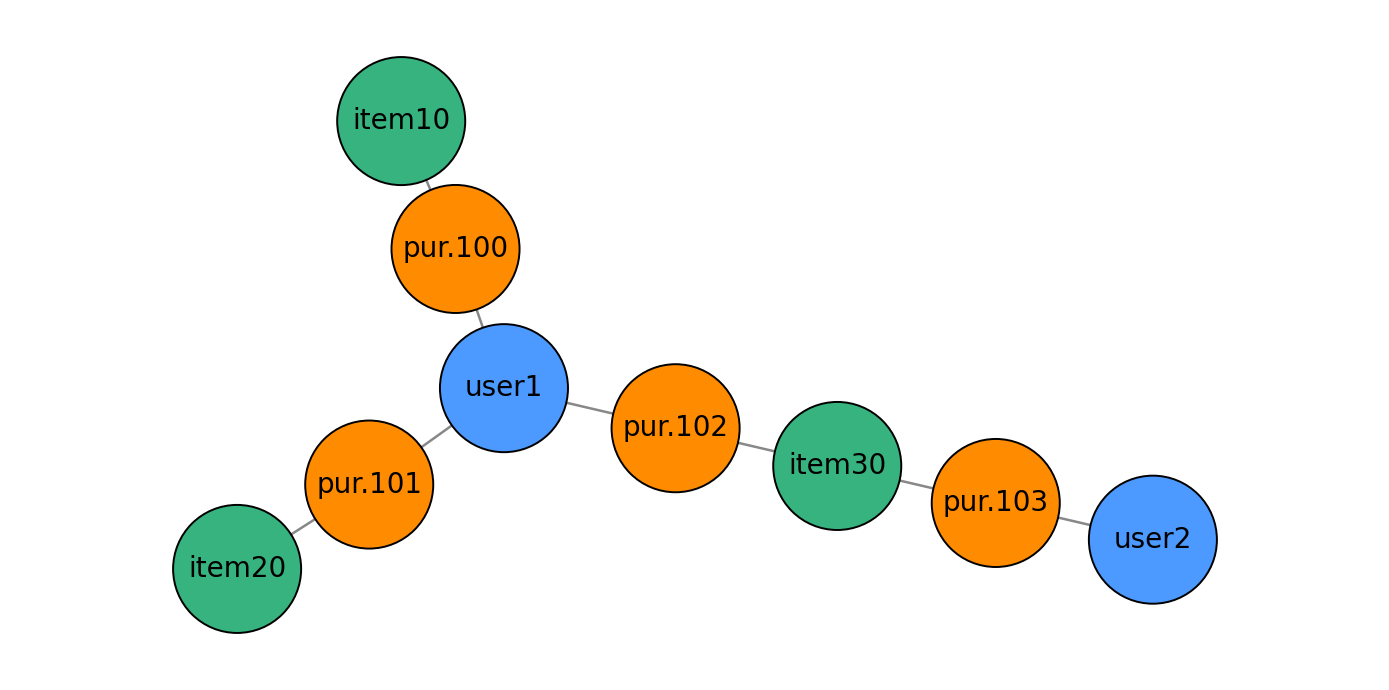

In [19]:
import matplotlib.pyplot as plt

LABEL_COLOR = {
    "User":     "#4C9AFF",  # blue
    "Item":     "#36B37E",  # green
    "Purchase": "#FF8B00",  # orange
}

node_colors = [LABEL_COLOR[d["label"]] for _, d in G.nodes(data=True)]
labels = {n: d["name"] for n, d in G.nodes(data=True)}
# rename "purchase" to "pur."
labels = {n: d["name"].replace("purchase", "pur.") for n, d in G.nodes(data=True)}
pos = nx.kamada_kawai_layout(G)
fig, ax = plt.subplots(figsize=(14, 7))
nx.draw_networkx_edges(G, pos, ax=ax, edge_color="#888", width=1.8)
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors,
                       node_size=8500, edgecolors="black", linewidths=1.4)
nx.draw_networkx_labels(G, pos, labels=labels, ax=ax, font_size=20)
ax.margins(0.18)
ax.set_axis_off()
plt.tight_layout()
plt.show()

### Node feature: degree

The simplest structural feature — number of neighbors per node.
We re-draw the graph with each label of the form `name (deg)`.

,name,degree
0,User 1,3
1,User 2,1
2,Item 10,1
3,Item 20,1
4,Item 30,2
5,Purchase 100,2
6,Purchase 101,2
7,Purchase 102,2
8,Purchase 103,2


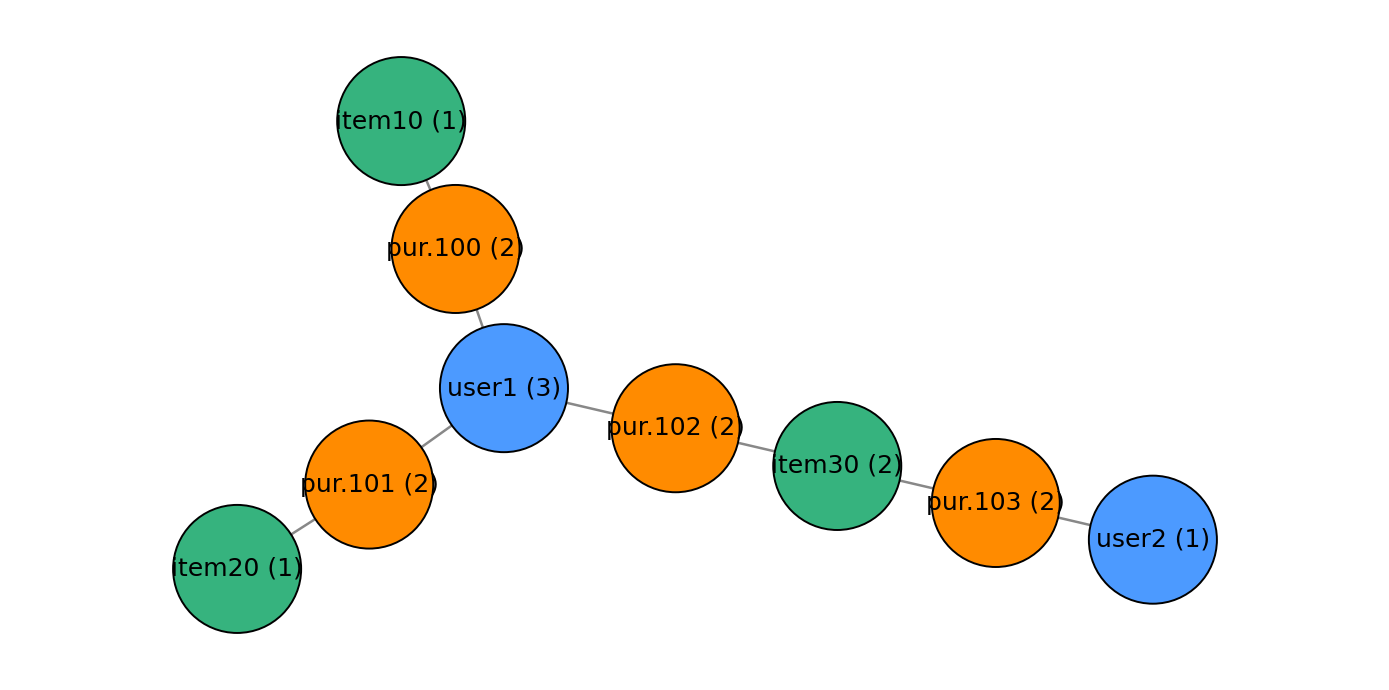

In [ ]:
degree = dict(G.degree())

from IPython.display import display

display(
    pd.DataFrame(
        [
            {
                "name": f"{n[0]} {n[1]}"
                if isinstance(n, tuple) and len(n) == 2
                else str(n),
                "degree": deg,
            }
            for n, deg in degree.items()
        ]
    )
)

deg_labels = {
    n: f"{d['name'].replace('purchase', 'pur.')} ({degree[n]})"
    for n, d in G.nodes(data=True)
}

fig, ax = plt.subplots(figsize=(14, 7))
nx.draw_networkx_edges(G, pos, ax=ax, edge_color="#888", width=1.8)
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors,
                       node_size=8500, edgecolors="black", linewidths=1.4)
nx.draw_networkx_labels(G, pos, labels=deg_labels, ax=ax, font_size=18)
ax.margins(0.18)
ax.set_axis_off()
plt.tight_layout()
plt.show()

### Add `degree` back to the purchases table

Structural feature → tabular feature: each purchase row gets the degree of its `Purchase` node.

In [27]:
from IPython.display import display

purchases["degree"] = purchases["purchase_id"].map(
    lambda pid: degree[("Purchase", pid)]
)

display(
    purchases.style
        .background_gradient(subset=["degree"], cmap="Oranges")
        .set_caption("Purchases — with structural feature `degree`")
        .hide(axis="index")
)

purchase_id,user_id,item_id,purchase_date,quantity,degree
100,1,10,2024-01-01,1,2
101,1,20,2024-01-10,2,2
102,1,30,2024-02-03,1,2
103,2,30,2024-03-15,1,2
